In [2]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import chi2_contingency, pearsonr, spearmanr, skew, kurtosis
from scipy import stats

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

# -------------------------
# 1) Point to your dataset
# -------------------------
DATA_PATH = r"/Users/manish/Documents/Ironhack/EDA_univariate/lab-eda-univariate/amz_uk_price_prediction_dataset.csv"   

def find_csv(path: str) -> str:
    if os.path.isfile(path) and path.lower().endswith(".csv"):
        return path
    if os.path.isdir(path):
        csvs = sorted(glob.glob(os.path.join(path, "*.csv")))
        if not csvs:
            raise FileNotFoundError(f"No CSV files found in directory: {path}")
        return csvs[0]
    raise FileNotFoundError(f"DATA_PATH not found: {path}")

csv_path = find_csv(DATA_PATH)
print("Using CSV:", csv_path)

df = pd.read_csv(csv_path, low_memory=False)
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

# -------------------------
# 2) Helper: find columns
# -------------------------
def find_col(candidates, columns):
    cols_lower = {c.lower(): c for c in columns}
    for cand in candidates:
        if cand.lower() in cols_lower:
            return cols_lower[cand.lower()]
    for cand in candidates:
        for c in columns:
            if cand.lower() in c.lower():
                return c
    return None

category_col = find_col(["category", "product_category", "main_category"], df.columns)
price_col    = find_col(["price", "product_price", "final_price", "sale_price"], df.columns)
rating_col   = find_col(["stars", "rating", "product_rating"], df.columns)   # lab says stars; dataset may say rating
best_col     = find_col(["isBestSeller", "isbestseller", "best_seller", "is_best_seller"], df.columns)
brand_col    = find_col(["brand", "manufacturer", "brand_name"], df.columns) # dataset usually has brand

print("\nDetected columns:")
print("  category :", category_col)
print("  price    :", price_col)
print("  rating   :", rating_col)
print("  isBestSeller:", best_col)
print("  brand    :", brand_col)

required = [category_col, price_col, rating_col, best_col]
if any(c is None for c in required):
    raise ValueError(
        "Could not detect one or more required columns among: category, price, rating/stars, isBestSeller.\n"
        "Please inspect df.columns and extend the candidate lists if needed."
    )

# -------------------------
# 3) Cleaning key fields
# -------------------------
df_clean = df.copy()

# category
df_clean[category_col] = df_clean[category_col].astype(str).str.strip()

# price: remove currency symbols, commas, etc.
df_clean[price_col] = (
    df_clean[price_col]
    .astype(str)
    .str.replace(r"[^\d\.\-]", "", regex=True)
    .replace("", np.nan)
)
df_clean[price_col] = pd.to_numeric(df_clean[price_col], errors="coerce")

# rating/stars
df_clean[rating_col] = pd.to_numeric(df_clean[rating_col], errors="coerce")

# isBestSeller: normalize to 0/1
def normalize_bool_series(s: pd.Series) -> pd.Series:
    # Accepts: True/False, 1/0, "true"/"false", "yes"/"no", etc.
    if s.dtype == bool:
        return s.astype(int)
    if pd.api.types.is_numeric_dtype(s):
        # convert to 0/1 if values look like that
        return (s.fillna(0).astype(float) != 0).astype(int)
    s2 = s.astype(str).str.strip().str.lower()
    true_set  = {"true", "1", "yes", "y", "t"}
    false_set = {"false", "0", "no", "n", "f", "nan", "none", ""}
    out = np.where(s2.isin(true_set), 1,
          np.where(s2.isin(false_set), 0, np.nan))
    return pd.Series(out, index=s.index, dtype="float").astype("Int64")

df_clean[best_col] = normalize_bool_series(df_clean[best_col])

# Optional: brand clean (only if present)
if brand_col is not None:
    df_clean[brand_col] = df_clean[brand_col].astype(str).str.strip()

# Keep only rows where these exist for relevant analyses
print("\nMissing % (key cols):")
print(df_clean[[category_col, price_col, rating_col, best_col]].isna().mean().mul(100).round(2))

df_clean.head()

Using CSV: /Users/manish/Documents/Ironhack/EDA_univariate/lab-eda-univariate/amz_uk_price_prediction_dataset.csv
Shape: (2443651, 9)
Columns: ['uid', 'asin', 'title', 'stars', 'reviews', 'price', 'isBestSeller', 'boughtInLastMonth', 'category']

Detected columns:
  category : category
  price    : price
  rating   : stars
  isBestSeller: isBestSeller
  brand    : None

Missing % (key cols):
category        0.0
price           0.0
stars           0.0
isBestSeller    0.0
dtype: float64


,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,0,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,1,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,0,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,0,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,0,0,Hi-Fi Speakers


In [3]:
# ============================================
# Part 1.1: Crosstab category x isBestSeller
# ============================================

df_bs = df_clean.dropna(subset=[category_col, best_col]).copy()
df_bs[best_col] = df_bs[best_col].astype(int)

ct = pd.crosstab(df_bs[category_col], df_bs[best_col])
ct.columns = ["NotBestSeller", "BestSeller"] if len(ct.columns) == 2 else ct.columns
print("\nCrosstab (first 20 rows):")
print(ct.head(20))

# Best-seller proportion per category
# Ensure both columns exist
if "BestSeller" in ct.columns:
    bs_counts = ct["BestSeller"]
else:
    # if columns are 0/1
    bs_counts = ct.get(1, pd.Series(0, index=ct.index))

total_counts = ct.sum(axis=1)
bs_prop = (bs_counts / total_counts).fillna(0)

prop_table = (
    pd.DataFrame({
        "count_total": total_counts,
        "count_best_seller": bs_counts,
        "prop_best_seller": bs_prop
    })
    .sort_values(["prop_best_seller", "count_total"], ascending=[False, False])
)

print("\nTop categories by best-seller proportion (min 30 listings filter shown separately):")
print(prop_table.head(20).round(4))

# Optional: filter to avoid tiny categories dominating proportion
MIN_LISTINGS = 30
prop_table_filtered = prop_table[prop_table["count_total"] >= MIN_LISTINGS]
print(f"\nTop categories by best-seller proportion (count_total >= {MIN_LISTINGS}):")
print(prop_table_filtered.head(20).round(4))


Crosstab (first 20 rows):
                                   NotBestSeller  BestSeller
category                                                    
3D Printers                                  247           1
3D Printing & Scanning                      4065           2
Abrasive & Finishing Products                245           5
Action Cameras                              1696           1
Adapters                                     251           3
Agricultural Equipment & Supplies           8421         109
Alexa Built-In Devices                       106           1
Art & Craft Supplies                         253           5
Arts & Crafts                               9319         230
Baby                                       14709         341
Baby & Toddler Toys                         9332          24
Bakeware                                     233           6
Ballet & Dancing Footwear                   3238           2
Barebone PCs                                9478          

In [4]:
# ============================================
# Part 1.2: Chi-square + Cramér's V
# ============================================

# For chi-square we need a contingency table with >=2 categories and 2 columns.
# Also best_col should have both 0 and 1 present.
ct_for_test = ct.copy()

# Ensure there are at least 2 columns (0 and 1) - otherwise chi-square not meaningful
if ct_for_test.shape[1] < 2:
    raise ValueError("Best-seller column has only one class in the filtered data; Chi-square cannot be computed.")

chi2, p, dof, expected = chi2_contingency(ct_for_test.values)

n = ct_for_test.values.sum()
r, k = ct_for_test.shape
# Cramér's V = sqrt( chi2 / (n * (min(r-1, k-1))) )
cramers_v = np.sqrt(chi2 / (n * (min(r - 1, k - 1))))

print("\nChi-square test results:")
print(f"  chi2 = {chi2:.4f}")
print(f"  dof  = {dof}")
print(f"  p    = {p:.6g}")

print("\nCramér's V:")
print(f"  V = {cramers_v:.4f}")


Chi-square test results:
  chi2 = 36540.2027
  dof  = 295
  p    = 0

Cramér's V:
  V = 0.1223


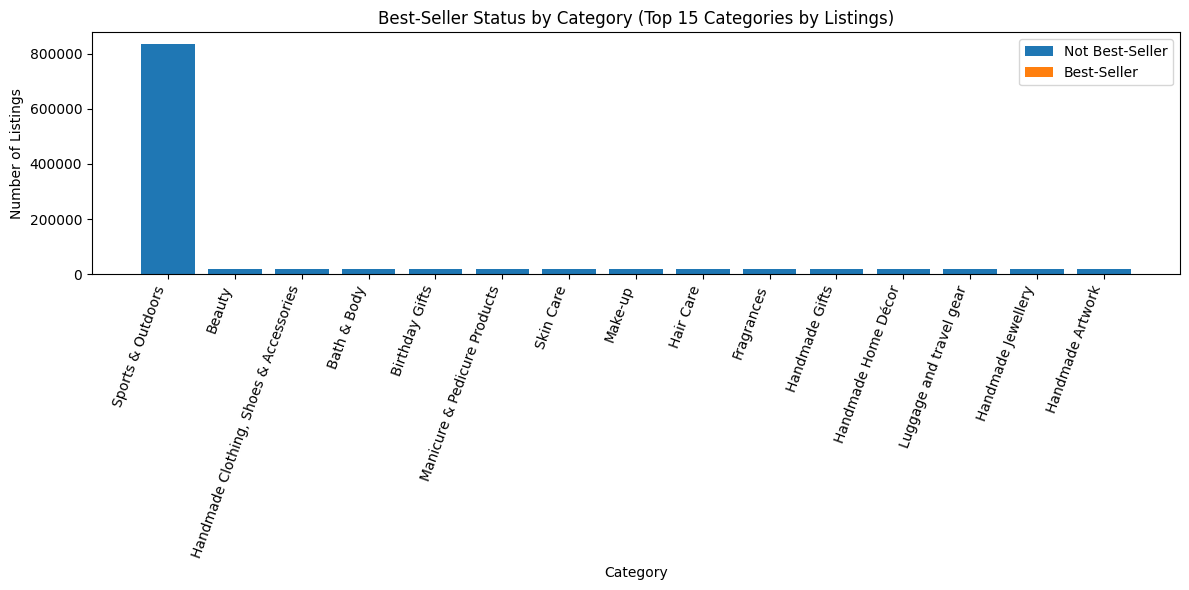

In [5]:
# ============================================
# Part 1.3: Stacked bar chart (top N categories by count)
# ============================================

TOP_N = 15
top_categories = total_counts.sort_values(ascending=False).head(TOP_N).index
ct_top = ct.loc[top_categories].copy()

# Make sure we have both columns
if "NotBestSeller" not in ct_top.columns and 0 in ct_top.columns:
    ct_top.rename(columns={0: "NotBestSeller"}, inplace=True)
if "BestSeller" not in ct_top.columns and 1 in ct_top.columns:
    ct_top.rename(columns={1: "BestSeller"}, inplace=True)

not_bs = ct_top["NotBestSeller"] if "NotBestSeller" in ct_top.columns else ct_top.iloc[:, 0]
bs     = ct_top["BestSeller"]    if "BestSeller" in ct_top.columns else ct_top.iloc[:, 1]

plt.figure(figsize=(12, 6))
plt.bar(ct_top.index.astype(str), not_bs.values, label="Not Best-Seller")
plt.bar(ct_top.index.astype(str), bs.values, bottom=not_bs.values, label="Best-Seller")
plt.title(f"Best-Seller Status by Category (Top {TOP_N} Categories by Listings)")
plt.xlabel("Category")
plt.ylabel("Number of Listings")
plt.xticks(rotation=70, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

In [6]:
# ============================================
# Part 2.0: Remove outliers using IQR on price
# ============================================

df_pr = df_clean.dropna(subset=[price_col]).copy()

q1 = df_pr[price_col].quantile(0.25)
q3 = df_pr[price_col].quantile(0.75)
iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

df_no_outliers = df_pr[(df_pr[price_col] >= lower) & (df_pr[price_col] <= upper)].copy()

print("\nIQR Outlier Removal Summary:")
print(f"  Q1={q1:.4f}, Q3={q3:.4f}, IQR={iqr:.4f}")
print(f"  Lower fence={lower:.4f}, Upper fence={upper:.4f}")
print(f"  Before: {df_pr.shape[0]} rows with price")
print(f"  After : {df_no_outliers.shape[0]} rows (outliers removed)")


IQR Outlier Removal Summary:
  Q1=9.9900, Q3=45.9900, IQR=36.0000
  Lower fence=-44.0100, Upper fence=99.9900
  Before: 2443651 rows with price
  After : 2115963 rows (outliers removed)


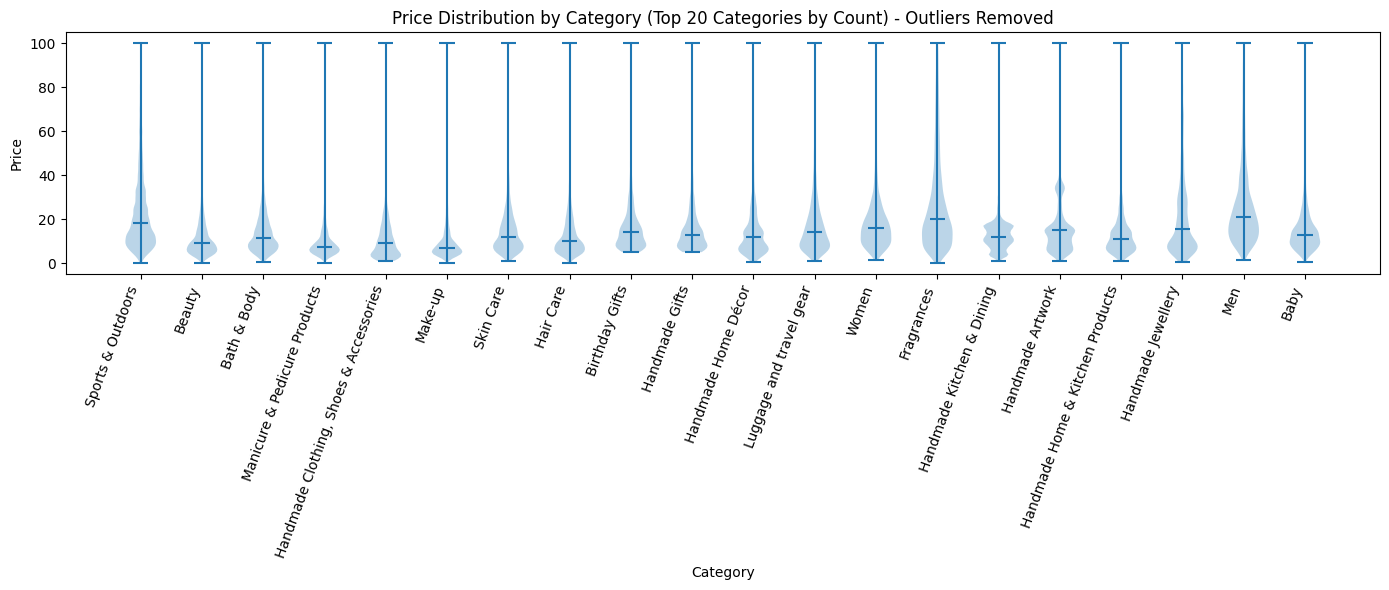


Category with highest median price (outliers removed, no category filtering):
category
Desktop PCs               74.00
Boxing Shoes              69.79
Tablets                   69.00
Graphics Cards            68.54
Motherboards              67.92
Made in Italy Handmade    64.00
Digital Frames            63.90
Streaming Clients         62.68
Golf Shoes                62.39
Ski Helmets               61.33
Name: price, dtype: float64

Top category by median price: Desktop PCs median= 74.0


In [7]:
# ============================================
# Part 2.1: Violin plot price by category (Top 20 by count)
# ============================================

df_pcat = df_no_outliers.dropna(subset=[category_col, price_col]).copy()

cat_counts = df_pcat[category_col].value_counts()
top20 = cat_counts.head(20).index

# Prepare data for violin plot
data = [df_pcat.loc[df_pcat[category_col] == c, price_col].values for c in top20]

plt.figure(figsize=(14, 6))
plt.violinplot(data, showmedians=True, showextrema=True)
plt.title("Price Distribution by Category (Top 20 Categories by Count) - Outliers Removed")
plt.xlabel("Category")
plt.ylabel("Price")
plt.xticks(range(1, len(top20) + 1), top20.astype(str), rotation=70, ha="right")
plt.tight_layout()
plt.show()

# Highest median price category (do NOT filter)
median_by_cat = (
    df_pcat.groupby(category_col)[price_col]
    .median()
    .sort_values(ascending=False)
)

print("\nCategory with highest median price (outliers removed, no category filtering):")
print(median_by_cat.head(10).round(4))
print("\nTop category by median price:", median_by_cat.index[0], "median=", float(median_by_cat.iloc[0]))

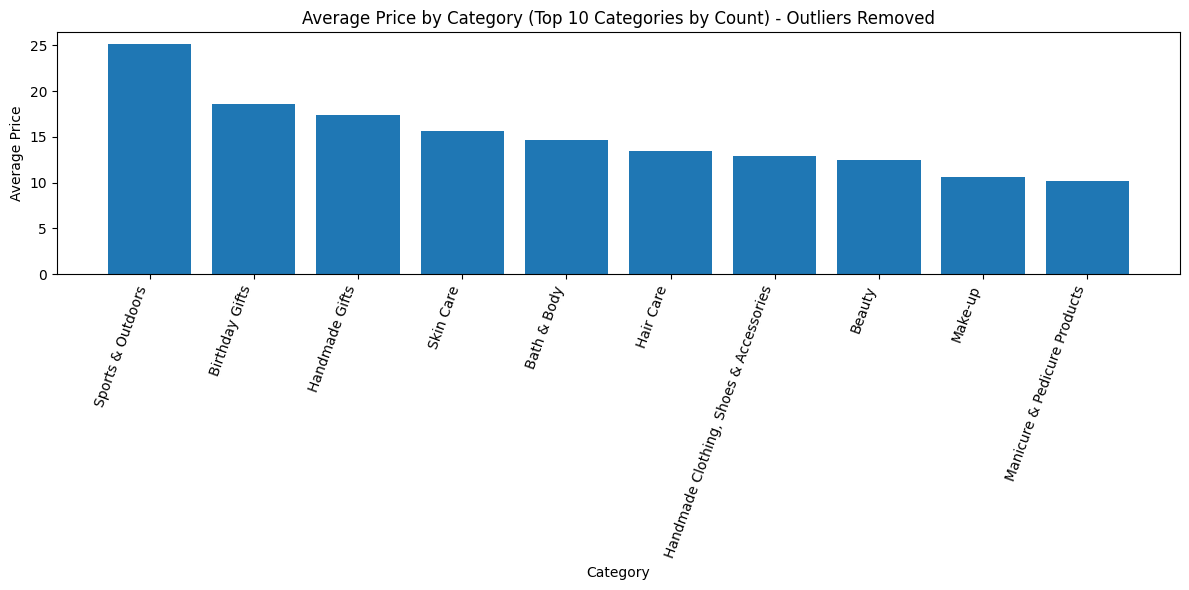


Category with highest average price (outliers removed, no category filtering):
category
Motherboards         68.7724
Boxing Shoes         67.4178
Desktop PCs          66.9156
Tablets              66.5530
Graphics Cards       65.1035
Digital Frames       60.7451
Streaming Clients    60.2418
Hockey Shoes         60.0948
Computer Cases       58.3399
Skiing Poles         57.8678
Name: price, dtype: float64

Top category by average price: Motherboards mean= 68.77243243243242


In [8]:
# ============================================
# Part 2.2: Bar chart average price by top 10 categories (Top 10 by count)
# ============================================

top10 = cat_counts.head(10).index

mean_price_top10 = (
    df_pcat[df_pcat[category_col].isin(top10)]
    .groupby(category_col)[price_col]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 6))
plt.bar(mean_price_top10.index.astype(str), mean_price_top10.values)
plt.title("Average Price by Category (Top 10 Categories by Count) - Outliers Removed")
plt.xlabel("Category")
plt.ylabel("Average Price")
plt.xticks(rotation=70, ha="right")
plt.tight_layout()
plt.show()

# Highest average price category (do NOT filter)
mean_by_cat = (
    df_pcat.groupby(category_col)[price_col]
    .mean()
    .sort_values(ascending=False)
)

print("\nCategory with highest average price (outliers removed, no category filtering):")
print(mean_by_cat.head(10).round(4))
print("\nTop category by average price:", mean_by_cat.index[0], "mean=", float(mean_by_cat.iloc[0]))

/var/folders/4c/sl3jt_wj26dgbkh3sqt9fmcm0000gn/T/ipykernel_67996/4263374857.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(box_data, labels=top10_r.astype(str), showfliers=False)


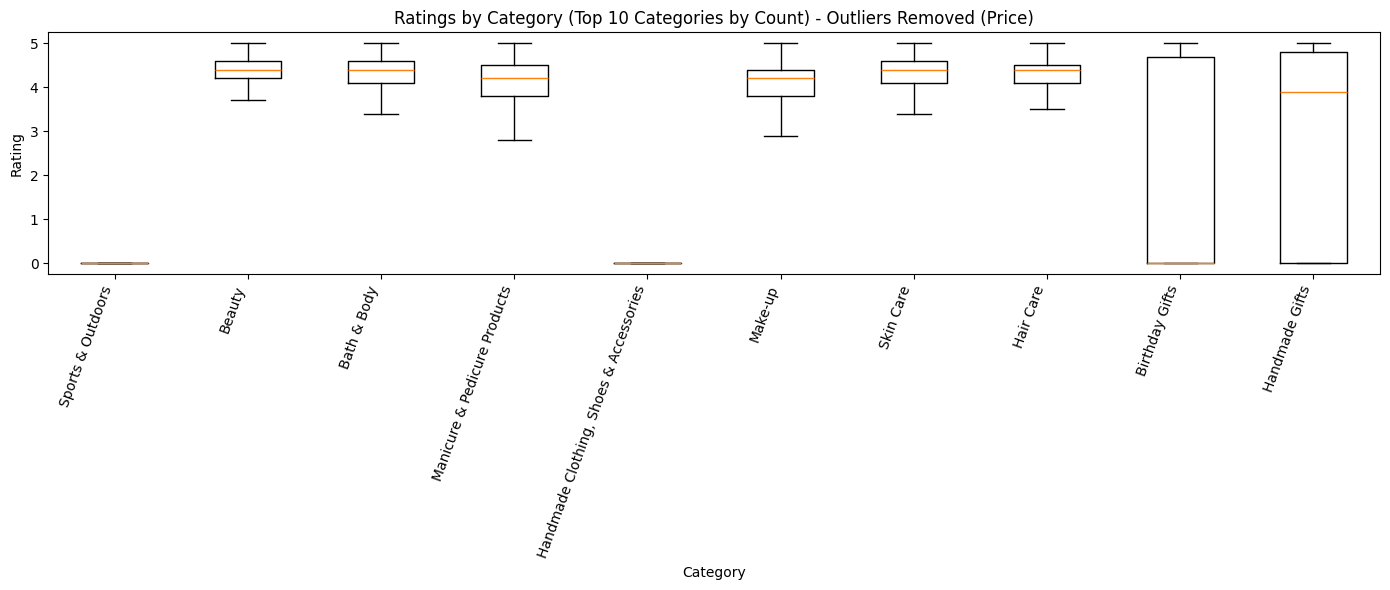


Category with highest median rating (outliers removed on price, no category filtering):
category
Computer Memory                 4.7
Building & Construction Toys    4.6
Office Paper Products           4.6
Luxury Food & Drink             4.6
Kids' Play Figures              4.6
Hobbies                         4.6
Beer, Wine & Spirits            4.6
Laptop Accessories              4.6
Cables & Accessories            4.5
CPUs                            4.5
Name: stars, dtype: float64

Top category by median rating: Computer Memory median= 4.7


In [9]:
# ============================================
# Part 2.3: Box plots of rating by category (Top 10 categories by count)
# ============================================

df_rcat = df_no_outliers.dropna(subset=[category_col, rating_col]).copy()

cat_counts_r = df_rcat[category_col].value_counts()
top10_r = cat_counts_r.head(10).index

box_data = [df_rcat.loc[df_rcat[category_col] == c, rating_col].values for c in top10_r]

plt.figure(figsize=(14, 6))
plt.boxplot(box_data, labels=top10_r.astype(str), showfliers=False)
plt.title("Ratings by Category (Top 10 Categories by Count) - Outliers Removed (Price)")
plt.xlabel("Category")
plt.ylabel("Rating")
plt.xticks(rotation=70, ha="right")
plt.tight_layout()
plt.show()

# Highest median rating category (do NOT filter)
median_rating_by_cat = (
    df_rcat.groupby(category_col)[rating_col]
    .median()
    .sort_values(ascending=False)
)

print("\nCategory with highest median rating (outliers removed on price, no category filtering):")
print(median_rating_by_cat.head(10).round(4))
print("\nTop category by median rating:", median_rating_by_cat.index[0], "median=", float(median_rating_by_cat.iloc[0]))

In [10]:
# OPTIONAL: Brand analysis (runs only if brand column is available)
if brand_col is not None:
    df_brand = df_no_outliers.dropna(subset=[brand_col, price_col]).copy()
    top_brands = df_brand[brand_col].value_counts().head(15).index

    mean_price_brand = (
        df_brand[df_brand[brand_col].isin(top_brands)]
        .groupby(brand_col)[price_col].mean()
        .sort_values(ascending=False)
    )

    plt.figure(figsize=(12, 6))
    plt.bar(mean_price_brand.index.astype(str), mean_price_brand.values)
    plt.title("Average Price by Brand (Top 15 Brands by Count) - Outliers Removed")
    plt.xlabel("Brand")
    plt.ylabel("Average Price")
    plt.xticks(rotation=70, ha="right")
    plt.tight_layout()
    plt.show()

    print("\nTop brands by average price (among top 15 brands by count):")
    print(mean_price_brand.round(4))

In [11]:
# ============================================
# Part 3.1: Correlation between price and rating
# ============================================

df_corr = df_no_outliers.dropna(subset=[price_col, rating_col]).copy()

x = df_corr[price_col].astype(float)
y = df_corr[rating_col].astype(float)

pearson_r, pearson_p = pearsonr(x, y)
spearman_r, spearman_p = spearmanr(x, y)

print("\nCorrelation (outliers removed on price):")
print(f"  Pearson r  = {pearson_r:.4f}, p = {pearson_p:.6g}")
print(f"  Spearman ρ = {spearman_r:.4f}, p = {spearman_p:.6g}")


Correlation (outliers removed on price):
  Pearson r  = -0.0777, p = 0
  Spearman ρ = -0.0668, p = 0


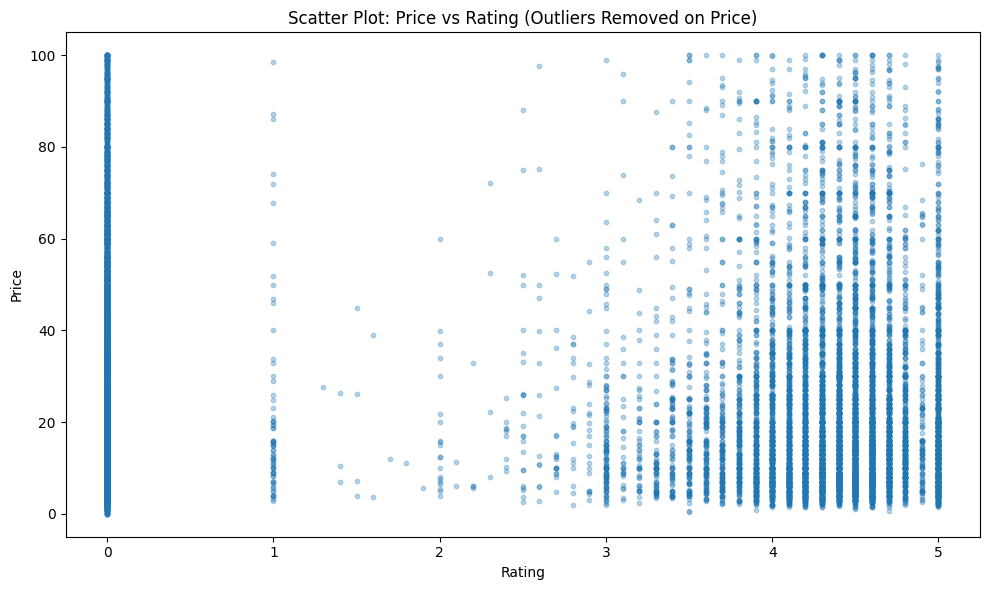

In [12]:
# ============================================
# Part 3.2a: Scatter plot price vs rating
# ============================================

# For performance/visibility, optionally sample if huge
MAX_POINTS = 20000
df_scatter = df_corr
if df_scatter.shape[0] > MAX_POINTS:
    df_scatter = df_scatter.sample(MAX_POINTS, random_state=42)

plt.figure(figsize=(10, 6))
plt.scatter(df_scatter[rating_col], df_scatter[price_col], s=10, alpha=0.3)
plt.title("Scatter Plot: Price vs Rating (Outliers Removed on Price)")
plt.xlabel("Rating")
plt.ylabel("Price")
plt.tight_layout()
plt.show()

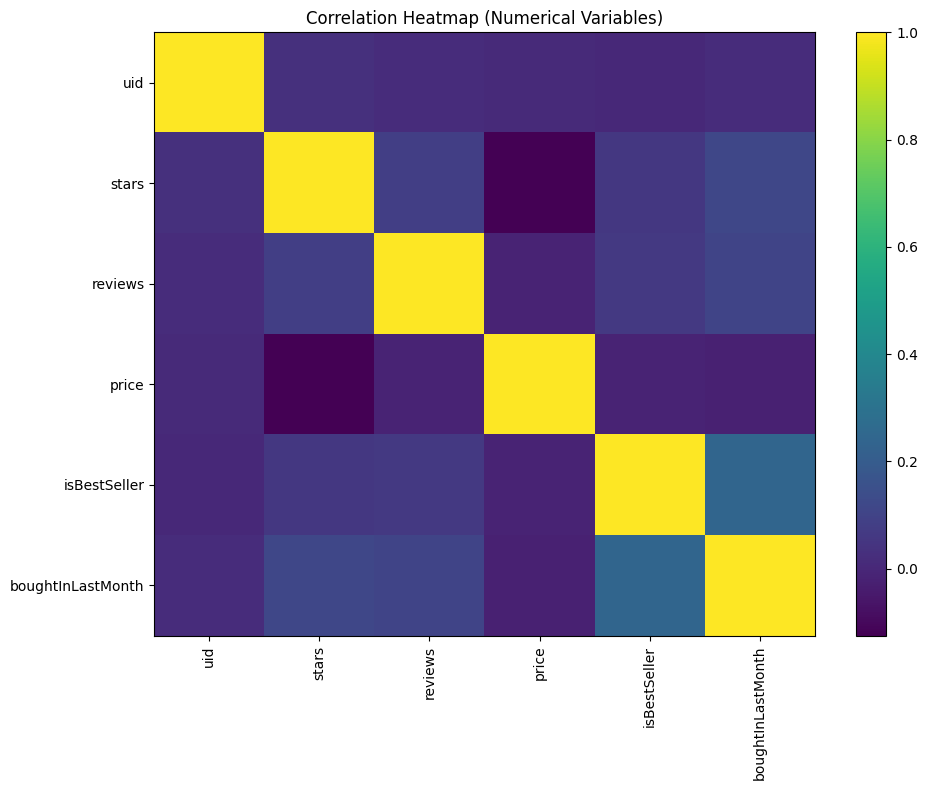


Top absolute correlations with price:
stars                0.124907
boughtInLastMonth    0.023439
reviews              0.013171
isBestSeller         0.011027
uid                  0.008273
Name: price, dtype: float64

Top absolute correlations with stars:
price                0.124907
boughtInLastMonth    0.112536
reviews              0.085808
isBestSeller         0.059215
uid                  0.031696
Name: stars, dtype: float64


In [13]:
# ============================================
# Part 3.2b: Correlation heatmap (all numeric columns)
# ============================================

num_df = df_clean.select_dtypes(include=[np.number]).copy()

# Ensure we have enough numeric columns
if num_df.shape[1] < 2:
    raise ValueError("Not enough numeric columns to compute a correlation heatmap.")

corr = num_df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
plt.imshow(corr.values, aspect="auto")
plt.title("Correlation Heatmap (Numerical Variables)")
plt.xticks(range(corr.shape[1]), corr.columns, rotation=90)
plt.yticks(range(corr.shape[0]), corr.index)
plt.colorbar()
plt.tight_layout()
plt.show()

# Print top correlations with price/rating if present
for target in [price_col, rating_col]:
    if target in corr.columns:
        print(f"\nTop absolute correlations with {target}:")
        s = corr[target].drop(labels=[target]).abs().sort_values(ascending=False).head(10)
        print(s)

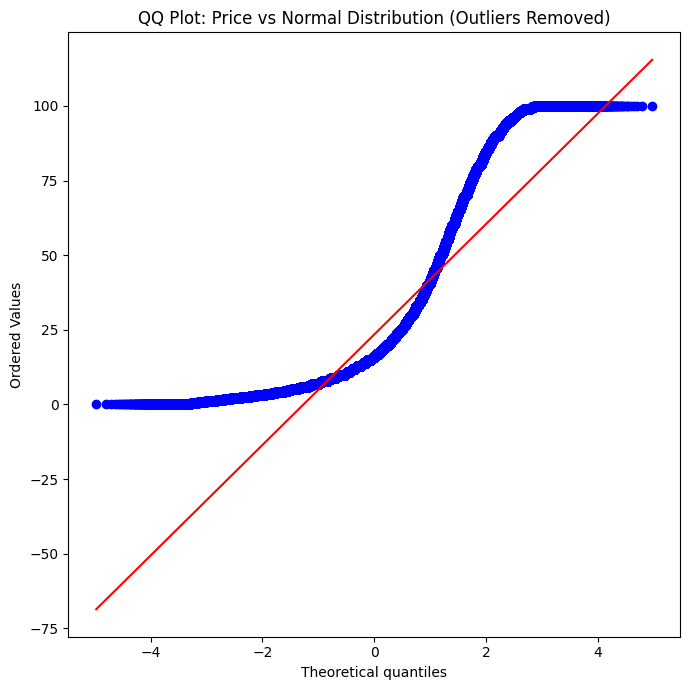

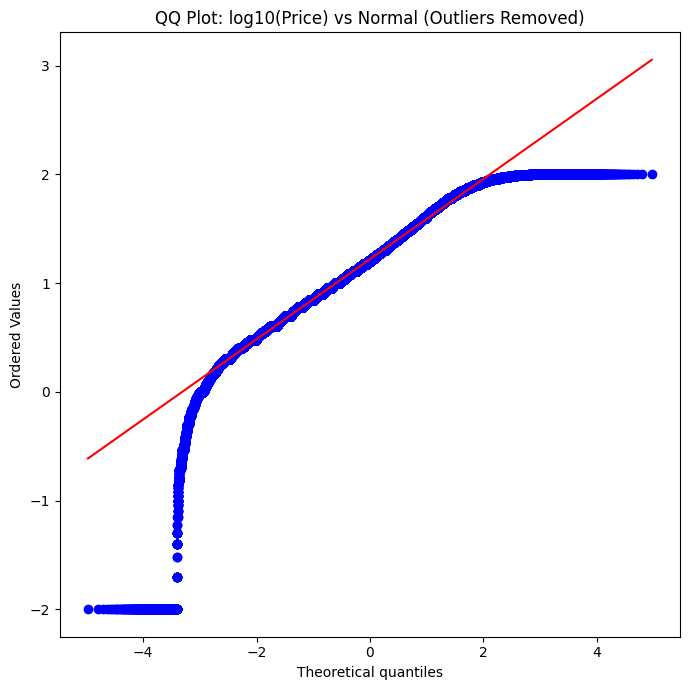

In [14]:
# ============================================
# Part 3.2c: QQ plot for normality of price
# ============================================

price_vals = df_no_outliers[price_col].dropna().astype(float).values

plt.figure(figsize=(7, 7))
stats.probplot(price_vals, dist="norm", plot=plt)
plt.title("QQ Plot: Price vs Normal Distribution (Outliers Removed)")
plt.tight_layout()
plt.show()

# Extra: QQ plot for log(price) often looks more normal for right-skew
price_pos = price_vals[price_vals > 0]
log_price = np.log10(price_pos)

plt.figure(figsize=(7, 7))
stats.probplot(log_price, dist="norm", plot=plt)
plt.title("QQ Plot: log10(Price) vs Normal (Outliers Removed)")
plt.tight_layout()
plt.show()

In [15]:
# ============================================
# Bonus A: Correlation without removing outliers
# ============================================

df_corr_raw = df_clean.dropna(subset=[price_col, rating_col]).copy()
x_raw = df_corr_raw[price_col].astype(float)
y_raw = df_corr_raw[rating_col].astype(float)

pearson_r_raw, pearson_p_raw = pearsonr(x_raw, y_raw)
spearman_r_raw, spearman_p_raw = spearmanr(x_raw, y_raw)

print("\nBONUS: Correlation (raw prices, no outlier removal):")
print(f"  Pearson r  = {pearson_r_raw:.4f}, p = {pearson_p_raw:.6g}")
print(f"  Spearman ρ = {spearman_r_raw:.4f}, p = {spearman_p_raw:.6g}")


BONUS: Correlation (raw prices, no outlier removal):
  Pearson r  = -0.1249, p = 0
  Spearman ρ = -0.1332, p = 0


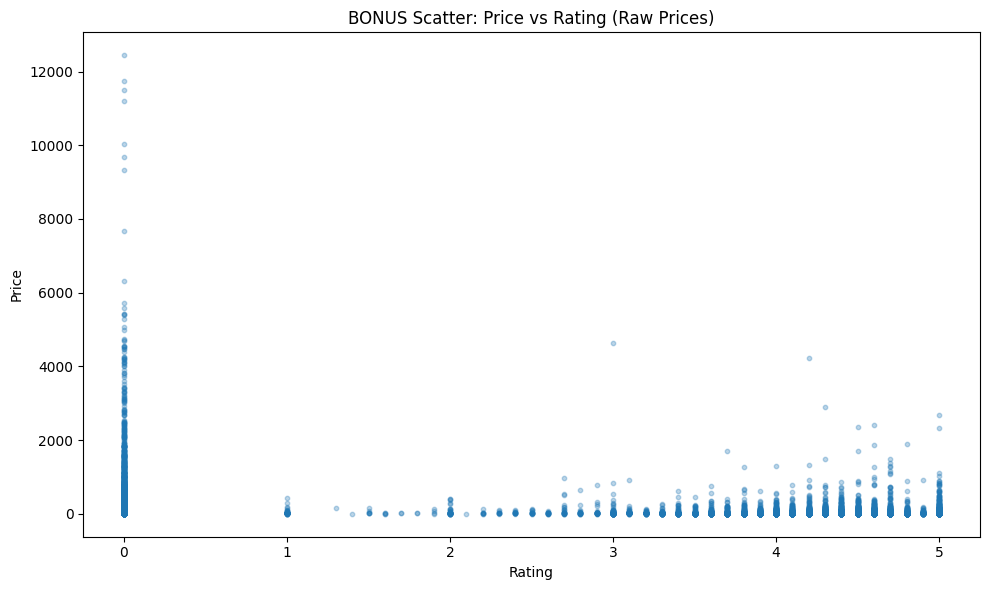

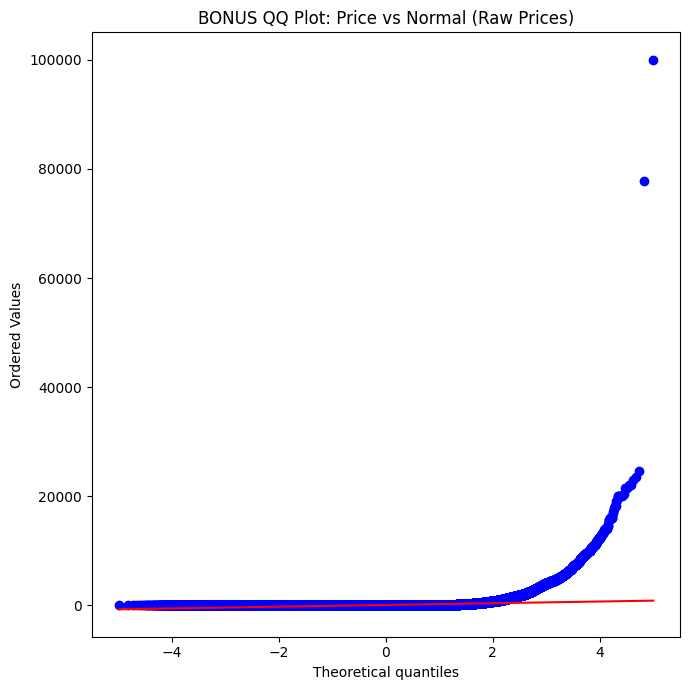

In [16]:
# Scatter raw (may be dominated by extreme prices)
df_scatter_raw = df_corr_raw
if df_scatter_raw.shape[0] > MAX_POINTS:
    df_scatter_raw = df_scatter_raw.sample(MAX_POINTS, random_state=42)

plt.figure(figsize=(10, 6))
plt.scatter(df_scatter_raw[rating_col], df_scatter_raw[price_col], s=10, alpha=0.3)
plt.title("BONUS Scatter: Price vs Rating (Raw Prices)")
plt.xlabel("Rating")
plt.ylabel("Price")
plt.tight_layout()
plt.show()

# QQ raw
price_vals_raw = df_corr_raw[price_col].dropna().astype(float).values
plt.figure(figsize=(7, 7))
stats.probplot(price_vals_raw, dist="norm", plot=plt)
plt.title("BONUS QQ Plot: Price vs Normal (Raw Prices)")
plt.tight_layout()
plt.show()